In [1]:
import pandas as pd

# carrega a tabela de pedidos
pedidos = pd.read_csv("../data/olist_orders_dataset.csv")
pedidos.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [2]:
print(pedidos.shape)
pedidos.info()

(99441, 8)
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [3]:
colunas_data = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in colunas_data:
    pedidos[col] = pd.to_datetime(pedidos[col])

pedidos.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [4]:
pedidos["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [5]:
sem_entrega = pedidos[pedidos["order_delivered_customer_date"].isna()]
sem_entrega["order_status"].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

## Valores faltando na tabela de pedidos

Percebi que, dentre as colunas de data, três têm valores vazios. A coluna "order_delivered_customer_date" apresenta 2.965 valores nulos e quase todos eles fazem sentido: são pedidos cancelados, em transporte ou ainda em processamento, então não devem mesmo ter data de entrega definida. No entanto, encontrei 8 pedidos com status "delivered" que não possuem data, o que configura uma inconsistência, já que pedidos marcados como entregues devem ter data de entrega definida. Como são poucos, decidi deixá-los de fora da análise de atraso.

In [6]:
entregues = pedidos[
    (pedidos["order_status"] == "delivered")
    & (pedidos["order_delivered_customer_date"].notna())
].copy()
entregues.shape

(96470, 8)

In [7]:
entregues["dias_atraso"] = (
    entregues["order_delivered_customer_date"]
    - entregues["order_estimated_delivery_date"]
).dt.days

entregues["dias_atraso"].describe()

count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: dias_atraso, dtype: float64

In [8]:
atrasados = entregues[entregues["dias_atraso"] > 0]
print(len(atrasados))
print(len(atrasados) / len(entregues) * 100)

6534
6.7730900798175595


In [9]:
avaliacoes = pd.read_csv("../data/olist_order_reviews_dataset.csv")
avaliacoes.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [10]:
print(avaliacoes.shape)
avaliacoes.info()

(99224, 7)
<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [11]:
avaliacoes["order_id"].nunique()

98673

In [12]:
avaliacoes["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [13]:
contagem = avaliacoes["order_id"].value_counts()
repetidos = contagem[contagem > 1]
print(len(repetidos))
repetidos.head()

547


order_id
c88b1d1b157a9999ce368f218a407141    3
df56136b8031ecd28e200bb18e6ddb2e    3
03c939fd7fd3b38f8485a0f95798f1f6    3
8e17072ec97ce29f0e1f111e598b0c85    3
cf73e2cb1f4a9480ed70c154da3d954a    2
Name: count, dtype: int64

In [14]:
exemplo = repetidos.index[0]
avaliacoes[avaliacoes["order_id"] == exemplo]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
1985,ffb8cff872a625632ac983eb1f88843c,c88b1d1b157a9999ce368f218a407141,3,NaN,NaN,2017-07-22 00:00:00,2017-07-26 13:41:07
82525,202b5f44d09cd3cfc0d6bd12f01b044c,c88b1d1b157a9999ce368f218a407141,5,NaN,NaN,2017-07-22 00:00:00,2017-07-26 13:40:22
89360,fb96ea2ef8cce1c888f4d45c8e22b793,c88b1d1b157a9999ce368f218a407141,5,NaN,NaN,2017-07-21 00:00:00,2017-07-26 13:45:15


In [15]:
repetidas = avaliacoes[avaliacoes["order_id"].isin(repetidos.index)]
notas_distintas = repetidas.groupby("order_id")["review_score"].nunique()
(notas_distintas > 1).sum()

np.int64(202)

In [16]:
avaliacoes["review_answer_timestamp"] = pd.to_datetime(avaliacoes["review_answer_timestamp"])

In [17]:
avaliacoes_unicas = (
    avaliacoes
    .sort_values("review_answer_timestamp")
    .drop_duplicates(subset="order_id", keep="last")
)
print(avaliacoes_unicas.shape)
avaliacoes_unicas["order_id"].nunique()

(98673, 7)


98673

In [18]:
base = entregues.merge(
    avaliacoes_unicas[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)
print(base.shape)
print(len(entregues) - len(base))

(95824, 10)
646


In [19]:
base["atrasado"] = base["dias_atraso"] > 0

base.groupby("atrasado")["review_score"].agg(["count", "mean"])

,count,mean
atrasado,,
False,89443,4.290386
True,6381,2.270491


In [20]:
faixas = pd.cut(
    base["dias_atraso"],
    bins=[-200, 0, 3, 7, 15, 200],
    labels=["no prazo", "1 a 3 dias", "4 a 7 dias", "8 a 15 dias", "mais de 15 dias"]
)

base.groupby(faixas, observed=True)["review_score"].agg(["count", "mean"])

,count,mean
dias_atraso,,
no prazo,89443,4.290386
1 a 3 dias,1852,3.291037
4 a 7 dias,1748,2.102975
8 a 15 dias,1601,1.673954
mais de 15 dias,1180,1.726271


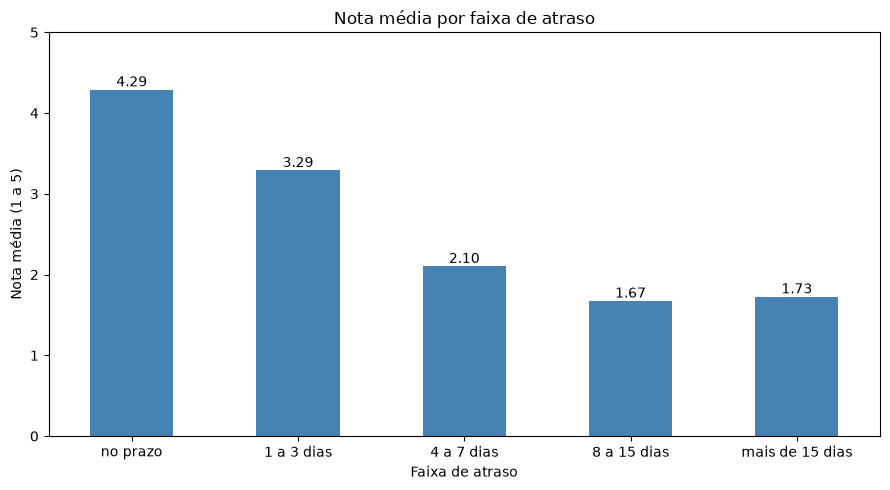

In [21]:
import matplotlib.pyplot as plt

media_por_faixa = base.groupby(faixas, observed=True)["review_score"].mean()

ax = media_por_faixa.plot(kind="bar", color="steelblue", figsize=(9, 5))
ax.bar_label(ax.containers[0], fmt="%.2f")
plt.title("Nota média por faixa de atraso")
plt.xlabel("Faixa de atraso")
plt.ylabel("Nota média (1 a 5)")
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig("../images/nota_por_atraso.png", dpi=150)
plt.show()

## Atraso na entrega e nota de avaliação

Dos 95.824 pedidos entregues que têm avaliação, 6.381 (cerca de 6,7%) chegaram depois do prazo estimado. A nota média desses pedidos foi de 2,27, contra 4,29 dos pedidos que chegaram no prazo. Ou seja, quem recebeu atrasado avaliou, em média, pouco mais de dois pontos abaixo.

Dividindo os atrasos em faixas, percebi que a maior queda acontece na primeira semana: a nota vai de 4,29 no prazo para 3,29 com 1 a 3 dias de atraso, e então desce novamente para 2,10 com 4 a 7 dias; a partir de 8 dias após o fim do prazo ela praticamente para de cair e fica perto de 1,7. Isso mostra que atraso e nota baixa andam juntos, mas não prova que o atraso é a única causa, uma vez que um pedido atrasado pode ter tido outros problemas também.

Para chegar nesses números, usei somente os pedidos entregues com avaliação, e nos 547 pedidos com mais de uma avaliação, fiquei com a mais recente, considerando que a última representa a decisão final do cliente.

In [22]:
itens = pd.read_csv("../data/olist_order_items_dataset.csv")
itens.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [23]:
print(itens.shape)
itens.info()

(112650, 7)
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [24]:
print(itens["order_id"].nunique())
itens["order_item_id"].max()

98666


np.int64(21)

In [25]:
itens[["price", "freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [26]:
sem_itens = pedidos[~pedidos["order_id"].isin(itens["order_id"])]
print(len(sem_itens))
sem_itens["order_status"].value_counts()

775


order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

In [27]:
vendas = itens.merge(
    pedidos[["order_id", "order_status", "order_purchase_timestamp"]],
    on="order_id",
    how="inner"
)
print(vendas.shape)

vendas = vendas[~vendas["order_status"].isin(["canceled", "unavailable"])]
print(vendas.shape)

(112650, 9)
(112101, 9)


In [28]:
vendas["mes"] = vendas["order_purchase_timestamp"].dt.to_period("M")
faturamento_mes = vendas.groupby("mes")["price"].sum()
faturamento_mes

mes
2016-09        207.86
2016-10      44507.30
2016-12         10.90
2017-01     120098.27
2017-02     244959.35
2017-03     368341.32
2017-04     353842.98
2017-05     503159.19
2017-06     429916.61
2017-07     492287.30
2017-08     568245.79
2017-09     621415.91
2017-10     660179.62
2017-11    1003862.14
2017-12     742183.79
2018-01     945456.29
2018-02     837895.43
2018-03     981051.06
2018-04     993592.98
2018-05     992871.75
2018-06     863265.53
2018-07     878044.27
2018-08     848860.10
2018-09        145.00
Freq: M, Name: price, dtype: float64

In [29]:
print(vendas["order_purchase_timestamp"].min())
print(vendas["order_purchase_timestamp"].max())
vendas.groupby("mes")["order_id"].nunique()

2016-09-04 21:15:19
2018-09-03 09:06:57


mes
2016-09       2
2016-10     290
2016-12       1
2017-01     787
2017-02    1718
2017-03    2617
2017-04    2377
2017-05    3640
2017-06    3205
2017-07    3946
2017-08    4272
2017-09    4227
2017-10    4547
2017-11    7421
2017-12    5618
2018-01    7187
2018-02    6624
2018-03    7168
2018-04    6919
2018-05    6833
2018-06    6145
2018-07    6233
2018-08    6421
2018-09       1
Freq: M, Name: order_id, dtype: int64

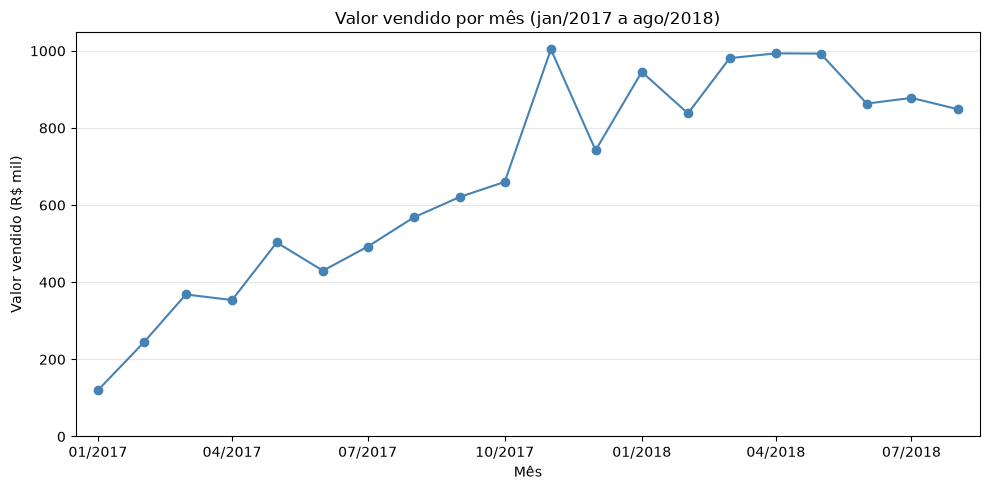

In [30]:
import matplotlib.dates as mdates

fat = faturamento_mes["2017-01":"2018-08"] / 1000
fat.index = fat.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fat.index, fat.values, marker="o", color="steelblue")
ax.set_xlim(fat.index.min() - pd.Timedelta(days=15), fat.index.max() + pd.Timedelta(days=15))
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))
ax.set_title("Valor vendido por mês (jan/2017 a ago/2018)")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor vendido (R$ mil)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("../images/vendas_por_mes.png", dpi=150)
plt.show()

In [31]:
nov = vendas[
    (vendas["order_purchase_timestamp"] >= "2017-11-01")
    & (vendas["order_purchase_timestamp"] < "2017-12-01")
]
por_dia = nov.groupby(nov["order_purchase_timestamp"].dt.date)["price"].sum()

print(por_dia.mean())
por_dia.sort_values(ascending=False).head(5)

33462.07133333334


order_purchase_timestamp
2017-11-24    152653.74
2017-11-25     60923.48
2017-11-27     47923.66
2017-11-28     47886.55
2017-11-26     44976.28
Name: price, dtype: float64

## Valor vendido por mês

Para medir as vendas, somei o preço (contido na coluna "price") dos itens vendidos em cada mês, usando a data da compra. Deixei o frete de fora, porque esse valor paga o transporte e não fica com o vendedor, e também tirei os pedidos cancelados e indisponíveis, uma vez que não chegaram a gerar vendas. Com isso, 549 dos 112.650 itens ficaram de fora. Chamei de valor vendido e não de faturamento porque a Olist é um marketplace, então o que estou somando é o que os lojistas venderam na plataforma, e não a receita da empresa.

No gráfico, usei só os meses de janeiro de 2017 a agosto de 2018. Os meses de 2016 têm pouquíssimos pedidos (2 em setembro, 290 em outubro e 1 em dezembro, enquanto novembro não tem nenhum), e setembro de 2018 tem só 1 pedido. Se eu incluísse esses meses, o gráfico mostraria quedas e subidas que na realidade correspondem a uma falta de dados.

O valor vendido cresceu ao longo de 2017, de R$ 120 mil em janeiro para R$ 660 mil em outubro, e chegou a R$ 1,00 milhão em novembro, o maior valor da série. Em dezembro caiu para R$ 742 mil. Olhando o valor vendido por dia em novembro, o dia 24 vendeu R$ 152,7 mil, cerca de 4,6 vezes a média diária do mês, e os cinco dias mais fortes ficaram todos entre 24 e 28 de novembro. O dia 24 foi a Black Friday daquele ano, segundo o g1, então o pico coincide com ela, mas os dados sozinhos não mostram que essa foi a causa.

Em 2018 os valores ficaram mais estáveis, entre uns R$ 840 mil e R$ 990 mil, mas de maio a agosto houve uma queda, de R$ 993 mil para R$ 849 mil. Os dados mostram essa queda, mas não explicam o motivo.

In [32]:
produtos = pd.read_csv("../data/olist_products_dataset.csv")
produtos.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [33]:
print(produtos.shape)
produtos.info()

(32951, 9)
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [34]:
traducao = pd.read_csv("../data/product_category_name_translation.csv")
print(traducao.shape)
traducao.head()

(71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [35]:
produtos["product_category_name"].isna().sum()

np.int64(610)

In [36]:
vendas_cat = vendas.merge(
    produtos[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)
print(vendas_cat.shape)
print(vendas_cat["product_category_name"].isna().sum())

(112101, 11)
1589


In [37]:
vendas_cat = vendas_cat.merge(traducao, on="product_category_name", how="left")

sem_trad = vendas_cat[
    vendas_cat["product_category_name"].notna()
    & vendas_cat["product_category_name_english"].isna()
]
print(vendas_cat.shape)
sem_trad["product_category_name"].value_counts()

(112101, 12)


product_category_name
portateis_cozinha_e_preparadores_de_alimentos    14
pc_gamer                                          8
Name: count, dtype: int64

In [38]:
vendas_cat["categoria"] = vendas_cat["product_category_name"].fillna("sem_categoria")

por_categoria = vendas_cat.groupby("categoria").agg(
    valor_vendido=("price", "sum"),
    itens=("order_id", "count"),
).sort_values("valor_vendido", ascending=False)

por_categoria.head(10)

,valor_vendido,itens
categoria,,
beleza_saude,1255695.13,9634
relogios_presentes,1198185.21,5970
cama_mesa_banho,1035964.06,11097
esporte_lazer,979740.92,8590
informatica_acessorios,904322.02,7781
moveis_decoracao,727465.05,8298
utilidades_domesticas,626825.80,6915
cool_stuff,620770.49,3779
automotivo,586585.73,4204


In [39]:
por_categoria["preco_medio"] = por_categoria["valor_vendido"] / por_categoria["itens"]

por_categoria.sort_values("itens", ascending=False).head(10)

,valor_vendido,itens,preco_medio
categoria,,,
cama_mesa_banho,1035964.06,11097,93.355327
beleza_saude,1255695.13,9634,130.339955
esporte_lazer,979740.92,8590,114.055986
moveis_decoracao,727465.05,8298,87.667516
informatica_acessorios,904322.02,7781,116.221825
utilidades_domesticas,626825.80,6915,90.647260
relogios_presentes,1198185.21,5970,200.701040
telefonia,322342.64,4527,71.204471
ferramentas_jardim,481009.94,4328,111.139080


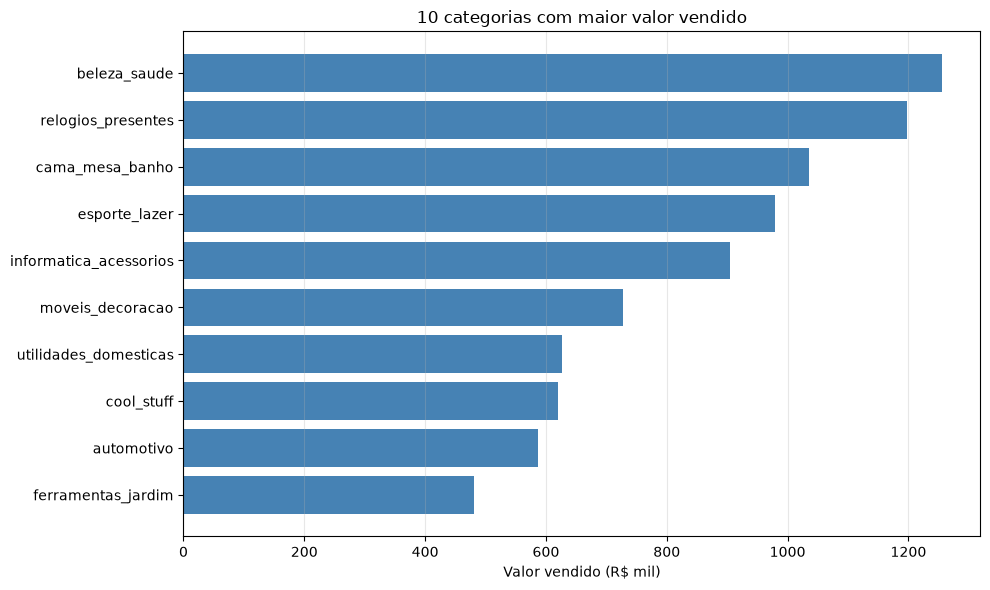

In [40]:
top = por_categoria.sort_values("valor_vendido", ascending=False).head(10)
top = top.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top.index, top["valor_vendido"] / 1000, color="steelblue")
ax.set_title("10 categorias com maior valor vendido")
ax.set_xlabel("Valor vendido (R$ mil)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig("../images/categorias_valor.png", dpi=150)
plt.show()

## Categorias que mais vendem

Para ver quais categorias vendem mais, usei o mesmo valor vendido da análise anterior (soma do preço dos itens, sem frete e sem pedidos cancelados ou indisponíveis) e agrupei por categoria de produto. Usei os nomes em português. Dos 112.101 itens, 1.589 (cerca de 1,4%) vêm de produtos sem categoria, e deixei esses itens na conta com o rótulo "sem_categoria", para o valor total continuar batendo.

Em valor vendido, as maiores categorias foram "beleza_saude" (R$ 1,26 milhão), "relogios_presentes" (R$ 1,20 milhão) e "cama_mesa_banho" (R$ 1,04 milhão), seguidas de "esporte_lazer" (R$ 980 mil) e "informatica_acessorios" (R$ 904 mil). As duas primeiras ficam bem próximas, e depois o valor vai caindo de forma regular.

O ranking por quantidade de itens é diferente. A categoria com mais itens vendidos é "cama_mesa_banho" (11.097), seguida de "beleza_saude" (9.634). Já "relogios_presentes" vendeu só 5.970 itens, mas ficou em segundo no gráfico de valor porque possui o preço médio mais alto da lista, cerca de R$ 201 por item. No sentido contrário, "telefonia" está entre as dez com mais itens (4.527), mas fica fora das dez primeiras em valor, com preço médio de cerca de R$ 71. Isso mostra que olhar só o valor ou só a quantidade dá uma imagem diferente de cada categoria.

Uma possível explicação é que categorias de uso recorrente, como "beleza_saude", vendam mais itens do que as de compra mais rara, como móveis, mas essa é só uma hipótese: os dados não mostram quantas vezes o mesmo cliente volta a comprar, e a diferença entre as duas categorias é pequena.

In [41]:
clientes = pd.read_csv("../data/olist_customers_dataset.csv")
clientes.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [42]:
print(clientes.shape)
clientes.info()

(99441, 5)
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [43]:
print(clientes["customer_id"].nunique())
print(clientes["customer_unique_id"].nunique())

99441
96096


In [44]:
estados_por_pessoa = clientes.groupby("customer_unique_id")["customer_state"].nunique()
(estados_por_pessoa > 1).sum()

np.int64(39)

In [45]:
por_estado = (
    clientes.drop_duplicates(subset="customer_unique_id")
    .groupby("customer_state")
    .size()
    .sort_values(ascending=False)
)

print(por_estado.head(10))
(por_estado / por_estado.sum() * 100).round(1).head(10)

customer_state
SP    40295
RJ    12377
MG    11255
RS     5277
PR     4882
SC     3529
BA     3276
DF     2073
ES     1963
GO     1951
dtype: int64


customer_state
SP    41.9
RJ    12.9
MG    11.7
RS     5.5
PR     5.1
SC     3.7
BA     3.4
DF     2.2
ES     2.0
GO     2.0
dtype: float64

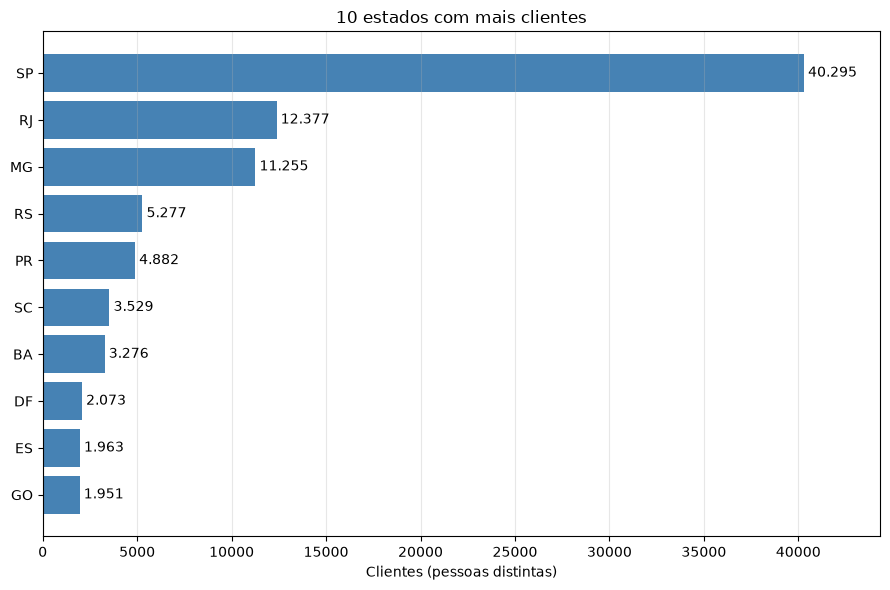

In [47]:
top_est = por_estado.head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 6))
barras = ax.barh(top_est.index, top_est.values, color="steelblue")
ax.bar_label(
    barras,
    labels=[f"{v:,.0f}".replace(",", ".") for v in top_est.values],
    padding=3,
)
ax.set_xlim(0, top_est.max() * 1.1)
ax.set_title("10 estados com mais clientes")
ax.set_xlabel("Clientes (pessoas distintas)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig("../images/clientes_por_estado.png", dpi=150)
plt.show()

## Estados com mais clientes

Para contar clientes, usei a coluna "customer_unique_id", que identifica a pessoa. A coluna "customer_id" não serve para isso, porque cada pedido gera um registro novo: ela tem 99.441 valores diferentes, um por pedido, enquanto "customer_unique_id" tem 96.096. Ou seja, 3.345 registros vêm de pessoas que compraram mais de uma vez. Também encontrei 39 pessoas que aparecem em mais de um estado, o que é muito pouco perto do total, e cada uma foi contada uma vez só.

São Paulo concentra 40.295 clientes, cerca de 41,9% do total. Em seguida vem Rio de Janeiro (12.377, 12,9%) e Minas Gerais (11.255, 11,7%), e os três juntos somam por volta de 66% dos clientes. Rio Grande do Sul (5,5%) e Paraná (5,1%) completam os cinco primeiros, e do sexto lugar em diante cada estado fica abaixo de 4%.

Os dados mostram onde os clientes estão, mas não explicam o motivo. Como São Paulo é o estado mais populoso do país, parte dessa concentração pode se dar apenas pelo tamanho da população. Para comparar por habitante, eu precisaria de uma fonte externa com a população de cada estado, que a base da Olist não possui.